# Two-part simulation study for resilience-induced blindness for the paper https://arxiv.org/abs/2606.29080

- **Part I:** one pre-specified illustrative realization, summarized in a compact two-panel figure.
- **Part II:** paired Monte Carlo analysis using common random numbers across all $r_s$ values, also summarized in two panels.

Relative state cost is $100 J(r_s)/J(0.25)$, so the baseline is exactly 100%. The aggregated detection delay is the sum of the delays over every switch in the trajectory.

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import solve_discrete_are

np.set_printoptions(precision=5, suppress=True)
OUT = Path("two_part_simulation_outputs")
FIG = OUT / "figures"
DATA = OUT / "data"
for d in (OUT, FIG, DATA):
    d.mkdir(parents=True, exist_ok=True)

# Exact initial-submission settings
n, m, p = 3, 1, 2
Tsim = 600
switch_interval = 200
Rscale_grid = np.array([0.25, 0.5, 1, 2, 4, 8, 16], dtype=float)
beta_baseline = 1.0
beta_mitigation = 6.0
belief_eps = 1e-12
noise_seed = 1

print("Tsim =", Tsim)
print("switch interval =", switch_interval)
print("R scales =", Rscale_grid)

A0 = np.array([[1.04, 0.10, 0.00],
               [0.00, 0.96, 0.08],
               [0.00, 0.00, 0.90]])
A1 = np.array([[1.24, 0.12, 0.00],
               [0.00, 1.14, 0.11],
               [0.00, 0.00, 0.96]])
B0 = np.array([[1.0000], [0.3500], [0.1500]])
B1 = np.array([[0.6500], [0.2275], [0.0975]])
C0 = np.array([[1.00, 0.00, 0.00],
               [0.00, 0.00, 1.00]])
C1 = np.array([[0.86, 0.00, 0.00],
               [0.00, 0.00, 0.90]])
A = (A0, A1); B = (B0, B1); C = (C0, C1)
Q = (2 * np.eye(n), 2 * np.eye(n))
Sigma_w_true = 0.01 * np.eye(n)
Sigma_v_true = 0.03 * np.eye(p)
Sigma_w_est = Sigma_w_true.copy()
Sigma_v_est = Sigma_v_true.copy()
Sigma_likelihood = 0.12 * np.eye(p)
x0 = np.array([2.0, -1.0, 0.8])

print("Open-loop spectral radii:", [max(abs(np.linalg.eigvals(M))) for M in A])

def symmetrize(M):
    return 0.5 * (M + M.T)


def dlqr(Ai, Bi, Qi, Ri):
    P = solve_discrete_are(Ai, Bi, Qi, Ri)
    K = np.linalg.solve(Ri + Bi.T @ P @ Bi, Bi.T @ P @ Ai)
    return K, P


def log_gaussian_residual(residual, covariance):
    covariance = symmetrize(covariance)
    L = np.linalg.cholesky(covariance)
    z = np.linalg.solve(L, residual)
    return -0.5 * (len(residual)*np.log(2*np.pi) + 2*np.sum(np.log(np.diag(L))) + z @ z)


def weighted_lqr(belief, R_design):
    Abar = belief[0]*A[0] + belief[1]*A[1]
    Bbar = belief[0]*B[0] + belief[1]*B[1]
    Qbar = belief[0]*Q[0] + belief[1]*Q[1]
    K, P = dlqr(Abar, Bbar, Qbar, R_design)
    return K, P

def run_simulation(mode_schedule, Rscale, beta):
    R_design = Rscale * np.eye(m)
    x = x0.copy()
    u_prev = np.zeros(m)

    # Same initialization rule as the MATLAB code: 0.6 on the initial true mode.
    belief = np.ones(2) / 2
    belief[mode_schedule[0]] = 0.60
    belief /= belief.sum()

    xhat_mode = np.zeros((n, 2))
    P_mode = np.stack([np.eye(n), np.eye(n)], axis=2)

    x_hist = np.zeros((n, Tsim))
    u_hist = np.zeros((m, Tsim))
    belief_hist = np.zeros((2, Tsim))
    p_true_hist = np.zeros(Tsim)
    stage_cost_hist = np.zeros(Tsim)
    gain_mismatch_hist = np.zeros(Tsim)
    logL_hist = np.zeros((2, Tsim))

    for k in range(Tsim):
        true_mode = int(mode_schedule[k])
        y = C[true_mode] @ x + v_noise[:, k]
        logL = np.zeros(2)

        # Two mode-conditioned Kalman-style observers.
        for i in range(2):
            x_pred = A[i] @ xhat_mode[:, i] + B[i] @ u_prev
            P_pred = symmetrize(A[i] @ P_mode[:, :, i] @ A[i].T + Sigma_w_est)
            y_pred = C[i] @ x_pred
            residual = y - y_pred
            logL[i] = log_gaussian_residual(residual, Sigma_likelihood)

            S_est = C[i] @ P_pred @ C[i].T + Sigma_v_est
            Lgain = np.linalg.solve(S_est.T, (P_pred @ C[i].T).T).T
            xhat_mode[:, i] = x_pred + Lgain @ residual
            I_KC = np.eye(n) - Lgain @ C[i]
            P_mode[:, :, i] = symmetrize(
                I_KC @ P_pred @ I_KC.T + Lgain @ Sigma_v_est @ Lgain.T
            )

        # Tempered Bayesian update in log space.
        log_weights = np.log(np.maximum(belief, belief_eps)) + beta * logL
        weights = np.exp(log_weights - np.max(log_weights))
        belief = weights / np.sum(weights)
        belief = np.maximum(belief, belief_eps)
        belief /= np.sum(belief)

        # Belief-weighted estimate and LQR controller.
        xhat = belief[0]*xhat_mode[:, 0] + belief[1]*xhat_mode[:, 1]
        K, _ = weighted_lqr(belief, R_design)
        u = -K @ xhat
        K_true, _ = dlqr(A[true_mode], B[true_mode], Q[true_mode], R_design)

        x_hist[:, k] = x
        u_hist[:, k] = u
        belief_hist[:, k] = belief
        p_true_hist[k] = belief[true_mode]
        stage_cost_hist[k] = x @ x
        gain_mismatch_hist[k] = np.linalg.norm(K - K_true, ord='fro')
        logL_hist[:, k] = logL

        x = A[true_mode] @ x + B[true_mode] @ u + w_noise[:, k]
        u_prev = u

    indicator_nominal = (mode_schedule == 0).astype(float)
    E_pi = np.sum(np.abs(belief_hist[0, :] - indicator_nominal))
    E_K = np.sum(gain_mismatch_hist)
    return {
        'J_total': float(np.sum(stage_cost_hist)),
        'E_pi': float(E_pi),
        'E_K': float(E_K),
        'x_hist': x_hist,
        'u_hist': u_hist,
        'belief_hist': belief_hist,
        'p_true_hist': p_true_hist,
        'stage_cost_hist': stage_cost_hist,
        'gain_mismatch_hist': gain_mismatch_hist,
        'logL_hist': logL_hist,
    }

Tsim = 600
switch interval = 200
R scales = [ 0.25  0.5   1.    2.    4.    8.   16.  ]
Open-loop spectral radii: [np.float64(1.04), np.float64(1.24)]


In [ ]:
# Study configuration
BASELINE_RS = 0.25
BETA_GRID = np.array([1.0, 4.0, 6.0, 8.0])
H_GRID = [260, 200, 300]
DETECTION_THRESHOLD = 0.99
DETECTION_HOLD = 1
RUN_MODE = "development"  # "smoke"=3, "development"=20, Monte Carlo seeds
N_MC = {"smoke": 3, "development": 20}[RUN_MODE]
MC_SEED_START = 1018

def make_noise(seed):
    rng = np.random.default_rng(seed)
    return (rng.multivariate_normal(np.zeros(n), Sigma_w_true, size=Tsim).T,
            rng.multivariate_normal(np.zeros(p), Sigma_v_true, size=Tsim).T)

def make_schedule(H):
    return (np.arange(Tsim) // H % 2).astype(int)

def set_noise(seed):
    global w_noise, v_noise
    w_noise, v_noise = make_noise(seed)

def sweep(schedule, beta):
    rows, outputs = [], []
    for rs in Rscale_grid:
        out = run_simulation(schedule, rs, beta)
        outputs.append(out)
        rows.append({"Rscale":rs,"J_total":out["J_total"],"E_pi":out["E_pi"],"E_K":out["E_K"]})
    return pd.DataFrame(rows), outputs

def relative_percent(df):
    base = float(df.loc[np.isclose(df.Rscale, BASELINE_RS), "J_total"].iloc[0])
    return 100.0 * df.J_total.to_numpy() / base

def detection_events(output, schedule, threshold=DETECTION_THRESHOLD, hold=DETECTION_HOLD):
    p = output["p_true_hist"]
    switches = np.flatnonzero(schedule[1:] != schedule[:-1]) + 1
    rows=[]
    for ks in switches:
        end = next((q for q in switches if q > ks), len(schedule))
        delay=np.nan
        for k in range(ks, max(ks, end-hold+1)):
            if np.all(p[k:k+hold] >= threshold):
                delay=float(k-ks); break
        rows.append({"switch_time":ks,"direction":f"{schedule[ks-1]}→{schedule[ks]}",
                     "delay":delay,"failure":not np.isfinite(delay)})
    return pd.DataFrame(rows)

set_noise(noise_seed)
mode_fixed = np.zeros(Tsim, dtype=int)
mode_switching = make_schedule(switch_interval)

def aggregate_detection_delay(output, schedule, threshold=DETECTION_THRESHOLD, hold=DETECTION_HOLD):
    """Sum detection delays over every switch in the trajectory.

    Returns NaN if any switch is not detected before the next switch, so a
    failed event is never silently removed from the aggregate.
    """
    events = detection_events(output, schedule, threshold, hold)
    if events.empty or events["failure"].any():
        return np.nan
    return float(events["delay"].sum())


## Part I: pre-specified illustrative realization

In [ ]:
# Part I simulations, all using the original seed-2 noise realization.
set_noise(noise_seed)
fixed_df, fixed_out = sweep(mode_fixed, 1.0)

# H=200 at all requested detector sensitivities.
part1_beta = {}
for beta in BETA_GRID:
    set_noise(noise_seed)
    part1_beta[float(beta)] = sweep(mode_switching, float(beta))

switch1_df, switch1_out = part1_beta[1.0]
switch4_df, switch4_out = part1_beta[4.0]
switch6_df, switch6_out = part1_beta[6.0]
switch8_df, switch8_out = part1_beta[8.0]

# Switching-period sensitivity at beta=1.
part1_H = {}
for H in H_GRID:
    set_noise(noise_seed)
    part1_H[int(H)] = sweep(make_schedule(H), 1.0)

part1_cost = pd.DataFrame({
    "Rscale": Rscale_grid,
    "Fixed, beta=1": relative_percent(fixed_df),
    **{f"H=200, beta={beta:g}": relative_percent(part1_beta[float(beta)][0]) for beta in BETA_GRID},
    "H=260, beta=1": relative_percent(part1_H[260][0]),
    "H=300, beta=1": relative_percent(part1_H[300][0]),
})
part1_cost.to_csv(DATA/"part1_relative_cost.csv", index=False)
print(part1_cost.to_string(index=False))

 Rscale  Fixed, beta=1  H=200, beta=1  H=200, beta=4  H=200, beta=6  H=200, beta=8  H=260, beta=1  H=300, beta=1
   0.25     100.000000     100.000000     100.000000     100.000000     100.000000     100.000000     100.000000
   0.50      99.811972      97.514565     100.166726      98.737322      98.863951     101.192040      86.196800
   1.00      99.721658      94.126051      92.610482      97.217943      97.896900      95.522103      83.407166
   2.00      99.877372      89.750131      91.079936      95.548743      97.626181      90.351500      85.686740
   4.00     100.446845      82.608934      89.556056      92.333490      97.993438      87.955119      85.309609
   8.00     101.623977      79.271382      87.020104      89.230113     115.230401      88.218021      89.249634
  16.00     103.657051      76.875012      87.378985      91.913393     119.100016      85.837057      95.421829


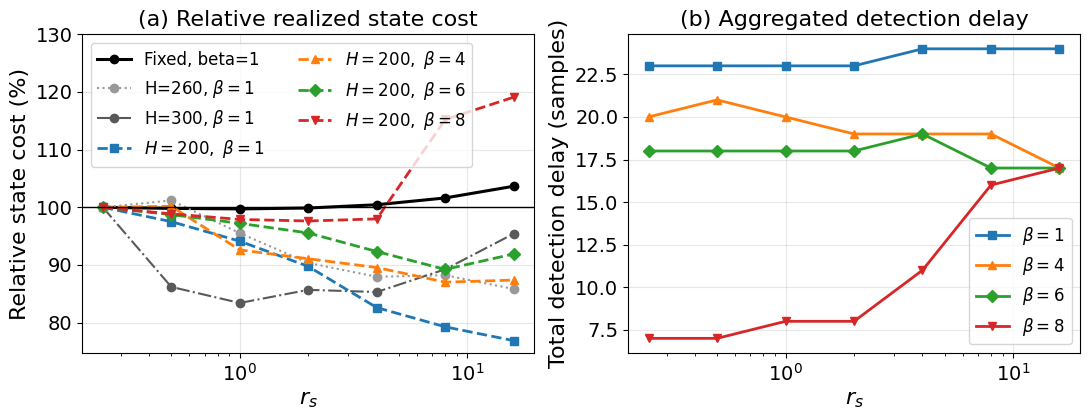

In [ ]:
# Figure 1: compact two-panel presentation for the illustrative realization.
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3))

# (a) Main cost panel: fixed case, switching-period sensitivity, and H=200 beta study.
ax = axes[0]
ax.plot(Rscale_grid, relative_percent(fixed_df), color="black", linestyle="-", marker="o",
        linewidth=2.2, label="Fixed, beta=1")
# Muted switching-period sensitivity at beta=1.
for H, color, ls in [(260,"0.60",":"),(300,"0.35","-.")]:
    ax.plot(Rscale_grid, relative_percent(part1_H[H][0]), color=color, linestyle=ls,
            marker="o", linewidth=1.5, label=rf"H={H}, $\beta=1$")
# H=200 uses color to encode beta and a common dashed family style.
colors = {1.0:"tab:blue",4.0:"tab:orange",6.0:"tab:green",8.0:"tab:red"}
markers = {1.0:"s",4.0:"^",6.0:"D",8.0:"v"}
for beta in BETA_GRID:
    df,_ = part1_beta[float(beta)]
    ax.plot(Rscale_grid, relative_percent(df), color=colors[float(beta)], linestyle="--",
            marker=markers[float(beta)], linewidth=2, label=rf"$H=200,\ \beta={beta:g}$")
ax.axhline(100, color="black", linewidth=1)
ax.set_xscale("log"); ax.set_xlabel(r"$r_s$", fontsize=16); ax.set_ylabel("Relative state cost (%)", fontsize=16)
ax.set_title("(a) Relative realized state cost",fontsize=16)
ax.tick_params(axis="both", labelsize=14)
ax.grid(True, alpha=.3); ax.legend(fontsize=12, ncol=2); ax.set_ylim(top=130)

# (b) Aggregate every switch delay in the trajectory, one curve per beta.
ax = axes[1]
delay_rows=[]
for beta in BETA_GRID:
    _, outputs = part1_beta[float(beta)]
    values=[]
    for rs, output in zip(Rscale_grid, outputs):
        events=detection_events(output, mode_switching)
        aggregate=aggregate_detection_delay(output, mode_switching)
        values.append(aggregate)
        for _,e in events.iterrows():
            delay_rows.append({"Rscale":rs,"beta":float(beta),
                               "aggregate_delay":aggregate,**e.to_dict()})
    ax.plot(Rscale_grid, values, color=colors[float(beta)], linestyle="-",
            marker=markers[float(beta)], linewidth=2, label=rf"$\beta={beta:g}$")
pd.DataFrame(delay_rows).to_csv(
    DATA/"part1_detection_delay_directional_and_aggregate.csv",index=False)
ax.set_xscale("log"); ax.set_xlabel(r"$r_s$", fontsize=16); ax.set_ylabel("Total detection delay (samples)", fontsize=16)
ax.set_title("(b) Aggregated detection delay",fontsize=16)
ax.tick_params(axis="both", labelsize=14)
ax.grid(True,alpha=.3); ax.legend(fontsize=12);

fig.tight_layout()
fig.savefig(FIG/"Figure1_part1_two_panels.png",dpi=300,bbox_inches="tight")
fig.savefig(FIG/"Figure1_part1_two_panels.pdf",bbox_inches="tight")
plt.show()

## Part II: paired Monte Carlo robustness study
Each seed generates one process-noise and one measurement-noise sequence. Those same sequences are reused for every $r_s$, scenario, and paired baseline comparison.

In [ ]:
def run_mc(N):
    rows=[]; delays=[]
    scenarios=[("Fixed, beta=1",mode_fixed,1.0)] + [
        (f"Switching, beta={beta:g}",mode_switching,float(beta)) for beta in BETA_GRID
    ]
    for mc in range(N):
        seed=MC_SEED_START+mc
        set_noise(seed)
        for name,sched,beta in scenarios:
            for rs in Rscale_grid:
                out=run_simulation(sched,rs,beta)
                rows.append({"mc":mc,"seed":seed,"scenario":name,"beta":beta,
                             "Rscale":rs,"J_total":out["J_total"]})
                if "Switching" in name:
                    ev=detection_events(out,sched)
                    aggregate=aggregate_detection_delay(out,sched)
                    for _,e in ev.iterrows():
                        delays.append({"mc":mc,"seed":seed,"scenario":name,"beta":beta,
                                       "Rscale":rs,"aggregate_delay":aggregate,**e.to_dict()})
    return pd.DataFrame(rows),pd.DataFrame(delays)

mc_runs,mc_delays=run_mc(N_MC)
base_cost=(mc_runs[np.isclose(mc_runs.Rscale,BASELINE_RS)]
           .set_index(["mc","scenario"])["J_total"])
mc_runs["relative_percent"]=[100*row.J_total/base_cost.loc[(row.mc,row.scenario)]
                             for row in mc_runs.itertuples()]
mc_runs.to_csv(DATA/"part2_mc_runs.csv",index=False)
mc_delays.to_csv(DATA/"part2_mc_detection_delay_directional_and_aggregate.csv",index=False)

Completed runs: 700 delay records: 1120


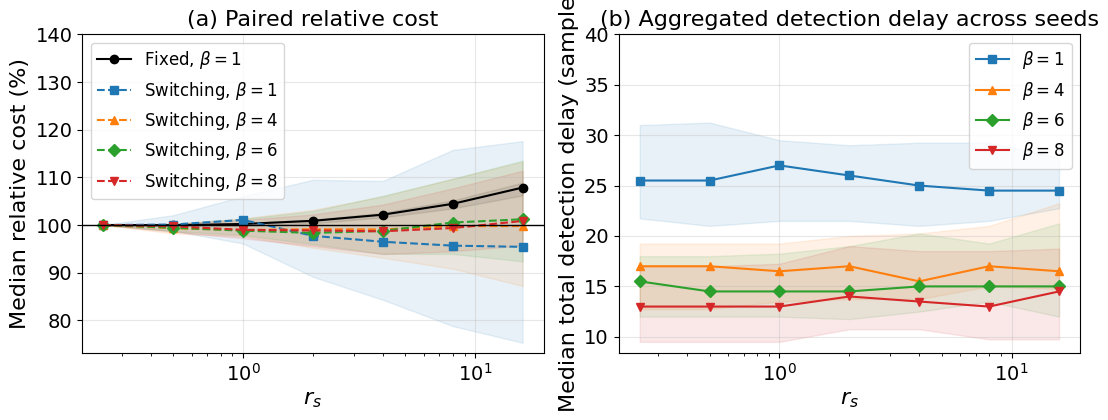

In [ ]:
# Figure 2: two-panel Monte Carlo counterpart.
fig,axes=plt.subplots(1,2,figsize=(11.0,4.3))

# (a) Paired relative cost, summarized by median and interquartile range.
ax = axes[0]

plot_specs = [("Fixed, beta=1", r"Fixed, $\beta=1$", "black", "-", "o")] + [
    (f"Switching, beta={b:g}", rf"Switching, $\beta={b:g}$", colors[float(b)],
        "--", markers[float(b)]
    )
    for b in BETA_GRID
]

for scenario_name, legend_label, color, ls, mk in plot_specs:
    g = (
        mc_runs[mc_runs.scenario == scenario_name]
        .groupby("Rscale")
        .relative_percent
    )

    med = g.median()
    q1 = g.quantile(0.25)
    q3 = g.quantile(0.75)

    ax.plot(
        med.index,
        med.values,
        color=color,
        linestyle=ls,
        marker=mk,
        label=legend_label
    )

    ax.fill_between(
        med.index,
        q1.values,
        q3.values,
        color=color,
        alpha=0.10
    )

ax.axhline(100, color="black", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel(r"$r_s$", fontsize=16)
ax.set_ylabel("Median relative cost (%)", fontsize=16)
ax.set_title("(a) Paired relative cost", fontsize=16)
ax.set_ylim(top=140)
ax.tick_params(axis="both", labelsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)


# (b) Aggregate all switch delays per realization,
# then summarize across seeds.
ax = axes[1]

aggregate = (
    mc_delays
    .drop_duplicates(["mc", "scenario", "Rscale"])
    .dropna(subset=["aggregate_delay"])
)

for beta in BETA_GRID:
    beta = float(beta)

    g = (
        aggregate[np.isclose(aggregate.beta, beta)]
        .groupby("Rscale")
        .aggregate_delay
    )

    med = g.median()
    q1 = g.quantile(0.25)
    q3 = g.quantile(0.75)

    ax.plot(
        med.index,
        med.values,
        color=colors[beta],
        marker=markers[beta],
        label=rf"$\beta={beta:g}$"
    )

    ax.fill_between(
        med.index,
        q1.values,
        q3.values,
        color=colors[beta],
        alpha=0.10
    )

ax.set_xscale("log")
ax.set_xlabel(r"$r_s$", fontsize=16)
ax.set_ylabel(
    "Median total detection delay (samples)",
    fontsize=16
)
ax.set_title(
    "(b) Aggregated detection delay across seeds",
    fontsize=16
)
ax.set_ylim(top=40)
ax.tick_params(axis="both", labelsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12,loc="upper right")


fig.tight_layout()
fig.savefig(FIG/"Figure2_part2_two_panels.png",dpi=300,bbox_inches="tight")
fig.savefig(FIG/"Figure2_part2_two_panels.pdf",bbox_inches="tight")
plt.show()

In [ ]:
# Sanity checks and reproducibility manifest.
assert np.allclose(part1_cost.filter(regex="Fixed|H=").iloc[0].to_numpy(float),100.0)
expected={"Fixed, beta=1"}|{f"Switching, beta={b:g}" for b in BETA_GRID}
assert set(mc_runs.scenario.unique())==expected
manifest={"seed_part1":noise_seed,"mc_seed_start":MC_SEED_START,"N_MC":N_MC,"run_mode":RUN_MODE,
          "Rscale_grid":Rscale_grid.tolist(),"H_GRID":H_GRID,"BETA_GRID":BETA_GRID.tolist(),
          "baseline_rs":BASELINE_RS,"detection_threshold":DETECTION_THRESHOLD,
          "detection_hold":DETECTION_HOLD,
          "aggregate_delay":"sum over all switch detection delays; NaN if any switch fails"}
(OUT/"manifest.json").write_text(json.dumps(manifest,indent=2))
print("All checks passed. Outputs:",OUT.resolve())

All checks passed. Outputs: /content/two_part_simulation_outputs
